# Student Pass/Fail Prediction — Data Cleaning & Feature Engineering

Handle missing values, engineer features, encode categoricals, save cleaned dataset.

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from utils import load_data, preprocess_data, create_features

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = load_data()
print('Raw shape:', df.shape)
df.head()

Raw shape: (1044, 32)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,course,passed
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,math,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,math,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,math,1
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,math,1
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,math,1


## 2. Handle Missing / Invalid Values

In [3]:
# UCI student dataset has no missing values.
print('Missing values:', df.isnull().sum().sum())
print('Shape:', df.shape)
df_clean = df.copy()

Missing values: 0
Shape: (1044, 32)


## 3. Imputation

In [4]:
print('NaN count:', df_clean.isnull().sum().sum())
df_imputed = df_clean.copy()

NaN count: 0


## 4. Distribution Comparison Before vs After Imputation

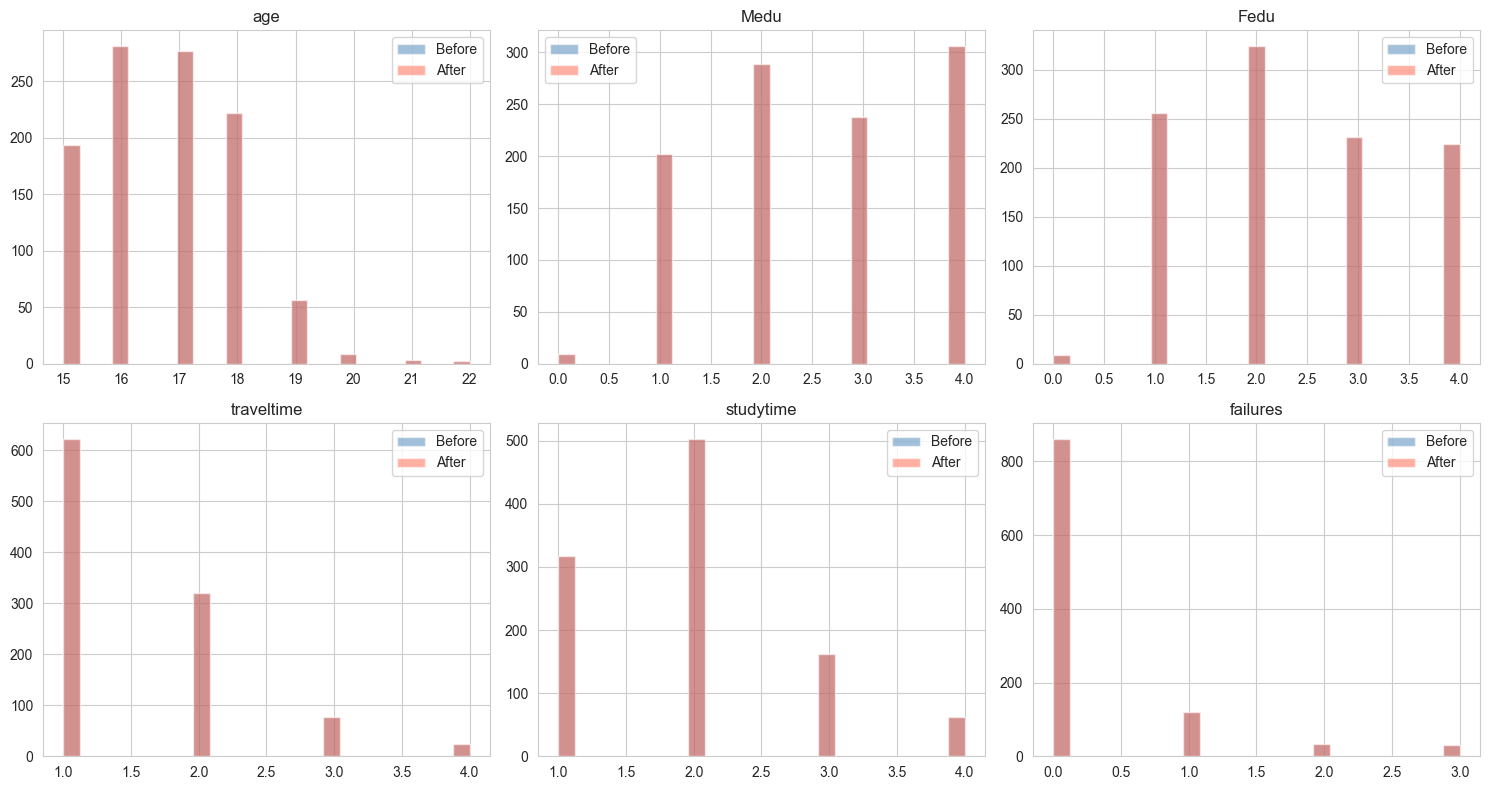

In [5]:
numeric_cols_for_plot = df.select_dtypes(include=[np.number]).columns[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_for_plot):
    if i >= 6: break
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=25, alpha=0.5, label='Before', color='steelblue')
    if col in df_imputed.columns:
        axes[i].hist(df_imputed[col], bins=25, alpha=0.5, label='After', color='tomato')
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

## 5. Feature Engineering

In [6]:
df_feat = create_features(df_imputed)
print('After feature engineering:', df_feat.shape)
df_feat.head()

After feature engineering: (1044, 38)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,course,passed,AlcoholScore,ParentEducation,FamilySupport,StudyAbsenceRatio,SocialActivityScore,AgeGroup
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,math,0,2,8,1,0.285714,7,18
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,math,0,2,2,1,0.400000,6,17
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,math,1,5,2,1,0.181818,5,15-16
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,math,1,2,6,1,1.000000,4,15-16
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,math,1,3,6,1,0.400000,5,15-16


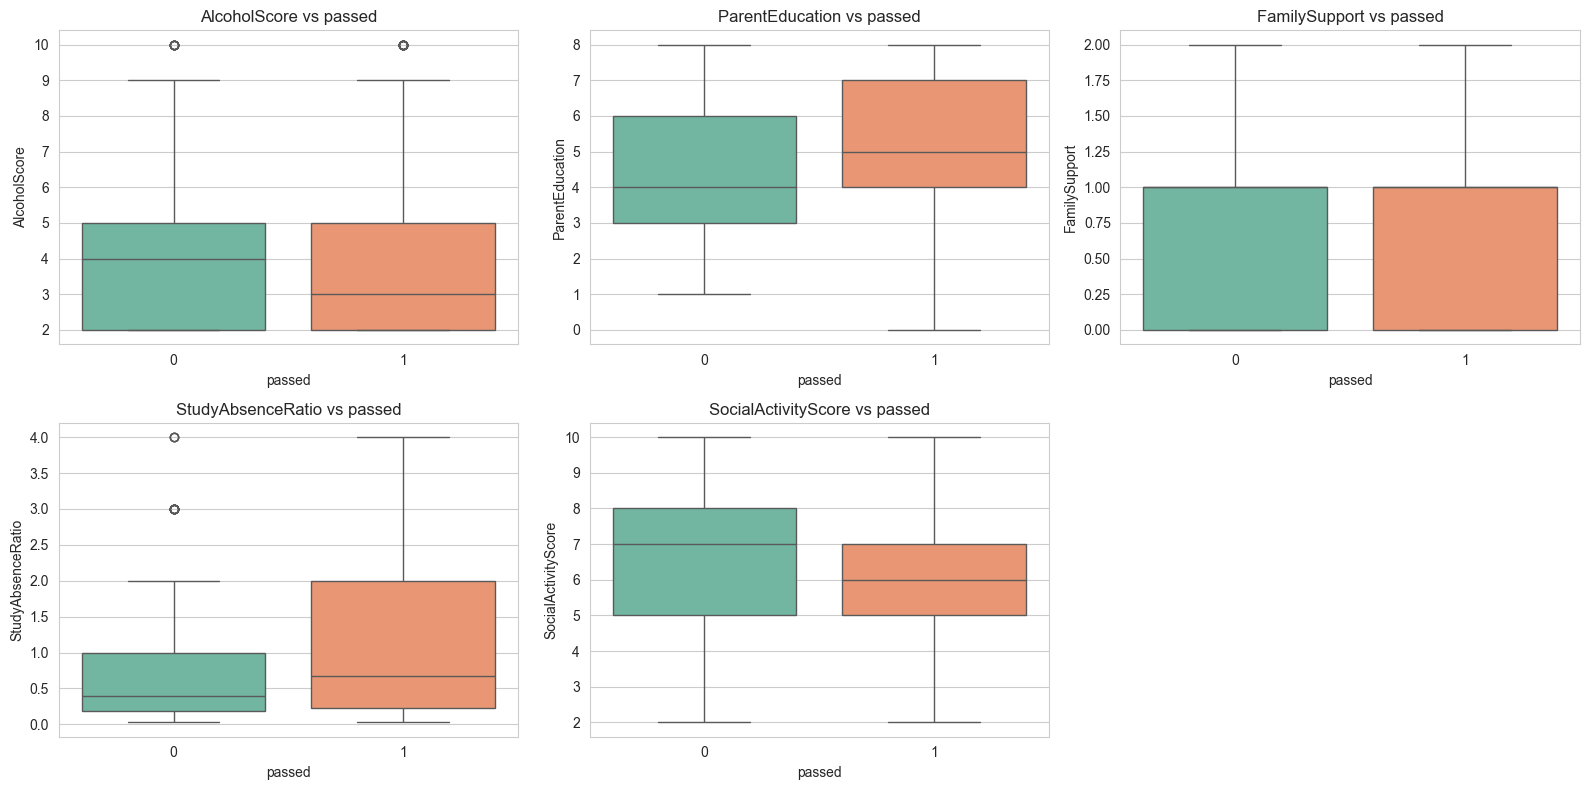

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(['AlcoholScore', 'ParentEducation', 'FamilySupport',
                          'StudyAbsenceRatio', 'SocialActivityScore']):
    if col in df_feat.columns:
        sns.boxplot(x='passed', y=col, data=df_feat, ax=axes[i], palette='Set2')
        axes[i].set_title(f'{col} vs passed')
axes[5].axis('off')
plt.tight_layout(); plt.show()

## 6. Encode Categorical Features

In [8]:
cat_cols = df_feat.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)
df_encoded = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print('After encoding:', df_encoded.shape)

Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'course', 'AgeGroup']
After encoding: (1044, 49)


## 7. Verify & Save Cleaned Dataset

In [9]:
print('Missing values:', df_encoded.isnull().sum().sum())
print('Final shape:', df_encoded.shape)
df_encoded.to_csv('data/student_cleaned.csv', index=False)
print('Saved -> data/student_cleaned.csv')
df_encoded.head()

Missing values: 0
Final shape: (1044, 49)
Saved -> data/student_cleaned.csv


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,passed,AlcoholScore,ParentEducation,FamilySupport,StudyAbsenceRatio,SocialActivityScore,school_MS,sex_M,address_U,famsize_LE3,Pstatus_T,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,course_portuguese,AgeGroup_17,AgeGroup_18,AgeGroup_19+
0,18,4,4,2,2,0,4,3,4,1,1,3,6,0,2,8,1,0.285714,7,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,1,0,0,0,0,1,0
1,17,1,1,1,2,0,5,3,3,1,1,3,4,0,2,2,1,0.400000,6,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0
2,15,1,1,1,2,3,4,3,2,2,3,3,10,1,5,2,1,0.181818,5,0,0,1,1,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,1,1,0,0,0,0,0
3,15,4,2,1,3,0,3,2,2,1,1,5,2,1,2,6,1,1.000000,4,0,0,1,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0,1,1,1,1,1,1,1,0,0,0,0
4,16,3,3,1,2,0,4,3,2,1,2,5,4,1,3,6,1,0.400000,5,0,0,1,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,1,0,1,1,0,0,0,0,0,0
